## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [15]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pandas.api.types import CategoricalDtype

df = pd.read_csv('../data/activities.csv')

C:\Users\jasmi\AppData\Local\Temp\ipykernel_24120\2475769979.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Month'] = df_2025['Date'].dt.month_name()
C:\Users\jasmi\AppData\Local\Temp\ipykernel_24120\2475769979.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Month'] = df_2025['Month'].astype(month_cat)


['February W7', 'February W8', 'February W9', 'March W9', 'March W10', 'March W11', 'March W12', 'March W13', 'April W14', 'April W15', 'April W16', 'April W17', 'May W18', 'May W19', 'May W20', 'May W21', 'May W22', 'June W23', 'June W24', 'June W25', 'June W26', 'July W27', 'July W28', 'July W29', 'July W30', 'July W31', 'August W31', 'August W32', 'August W33', 'August W34', 'September W36', 'September W37', 'September W38', 'September W39', 'September W40', 'October W40', 'October W41', 'October W42', 'October W43', 'October W44', 'November W44', 'November W45', 'November W46', 'November W47', 'November W48', 'December W1', 'December W49', 'December W50', 'December W51', 'December W52']


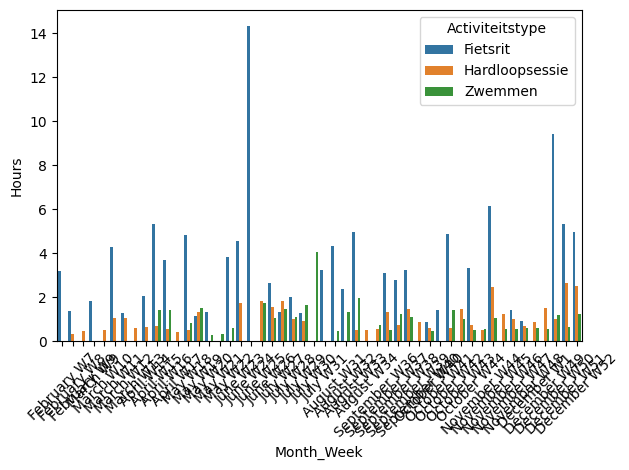

Empty DataFrame
Columns: [Month, Week, Activiteitstype, Beweegtijd, Hours, Month_Week]
Index: []


In [ ]:


# Load data
df = pd.read_csv('../data/activities.csv')

# Month translations
months = {
    'januari': 'January','februari': 'February','maart': 'March','april': 'April','mei': 'May',
    'juni': 'June','juli': 'July','augustus': 'August','september': 'September','oktober': 'October',
    'november': 'November','december': 'December','jan': 'January','feb': 'February','mrt': 'March',
    'apr': 'April','mei': 'May','jun': 'June','jul': 'July','aug': 'August','sep': 'September',
    'okt': 'October','nov': 'November','dec': 'December',
}

df['Datum van activiteit_en'] = df['Datum van activiteit'].str.lower()
for nl, en in months.items():
    df['Datum van activiteit_en'] = df['Datum van activiteit_en'].str.replace(nl, en, regex=False)

df['Datum van activiteit'] = pd.to_datetime(
    df['Datum van activiteit_en'],
    format='%d %B %Y, %H:%M:%S'
)
df.drop(columns='Datum van activiteit_en', inplace=True)
df = df[df['Afstand'] != 0]
df = df[df['Activiteitstype'] != 'Wandeling']
df =df[df['Activiteitstype'] != 'Training']

df['Date'] = df['Datum van activiteit']
df['Year'] = df['Datum van activiteit'].dt.year
df['Month'] = df['Datum van activiteit'].dt.month
df['Quarter'] = df['Datum van activiteit'].dt.quarter
df['Week'] = df['Datum van activiteit'].dt.isocalendar().week



# Filter 2025
df_2025 = df[df['Year'] == 2025]
df_2025['Month'] = df_2025['Date'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
month_cat = CategoricalDtype(categories=month_order, ordered=True)
df_2025['Month'] = df_2025['Month'].astype(month_cat)

df_weekly = (
    df_2025
    .groupby(['Month', 'Week', 'Activiteitstype'], observed=True, as_index=False)
    ['Beweegtijd']
    .sum()
)

df_weekly['Hours'] = df_weekly['Beweegtijd'] / 3600
df_weekly['Month_Week'] = df_weekly['Month'].astype(str) + " W" + df_weekly['Week'].astype(str)

# Create the correct order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# Ensure weeks within months are ordered
ordered_weeks = []
for month in month_order:
    weeks_in_month = df_weekly[df_weekly['Month'] == month]['Week'].sort_values().unique()
    for week in weeks_in_month:
        ordered_weeks.append(f"{month} W{week}")

# Set as categorical
month_week_cat = CategoricalDtype(categories=ordered_weeks, ordered=True)
df_weekly['Month_Week'] = df_weekly['Month_Week'].astype(month_week_cat)
print(df_weekly['Month_Week'].cat.categories.tolist())

sns.barplot(data=df_weekly, x='Month_Week', y='Hours', hue='Activiteitstype')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
